In [1]:
#Import modules
import scanpy as sc
import anndata as ad
import numpy as np

%pip install torch pyro-ppl

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.sparse as sp

# Silhouette scores
from sklearn.metrics import silhouette_score
import pandas as pd


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Read data
adata_source = '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/20260207_adata_preprocessed_full.h5ad'
adata = sc.read_h5ad(adata_source)

In [3]:
print(adata.obs['TMA'].unique())

[480 479]


In [4]:
#Pre-process data
adata_dense = adata.X.toarray() #Convert to dense array, in case future functions/libraries don't support a sparse matrix
tumor_mask = adata.obs['cell_type_general'] == 'tumor'
adata_tumor = adata[tumor_mask].copy() #Create an independent object to modify freely

# Separate into two pools: 479 and 480 only
adata_tma_479 = adata_tumor[adata_tumor.obs['TMA']==479].copy()
adata_tma_480 = adata_tumor[adata_tumor.obs['TMA']==480].copy()

adata_479_25k = sc.pp.subsample(adata_tma_479, n_obs=25000, random_state=5, copy=True)
adata_480_25k = sc.pp.subsample(adata_tma_480, n_obs=25000, random_state=5, copy=True)

adata_tumor_50k = sc.concat([adata_479_25k,adata_480_25k])

In [5]:
# Import native decipher
import sys
sys.path.insert(0, '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher')
import decipher as dc

/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
adata_tumor_dc=adata_tumor_50k.copy()
counts = adata_tumor_dc.layers['counts'].copy() #Decipher requires discrete integer counts, so we pull raw counts out of layers['counts']

# Block below fixes any floating point precision and writes back into adata.
if sp.issparse(counts):
    counts.data = counts.data.round().astype(int)
else:
    counts = counts.round().astype(int)
adata_tumor_dc.X = counts

adata_tumor_dc_orig = adata_tumor_dc.copy()

In [7]:
#Lower learning rate
from decipher.tools._decipher import DecipherConfig
config = DecipherConfig(learning_rate=1e-3,seed=5)

Epoch 19 (batch 703/703) | | train elbo: 240.04 (last epoch: 239.89) | val ll: 252.53:   2%|▏         | 19/1000 [02:10<1:52:21,  6.87s/it]2026-05-20 11:43:49,918 | INFO : Early stopping has been triggered.
2026-05-20 11:43:50,041 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-20 11:43:50,041 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-20 11:43:50,046 | INFO : Saving decipher model with run_id 2026-05-20-11-43-50-buoyant-fuchsia-waffle.


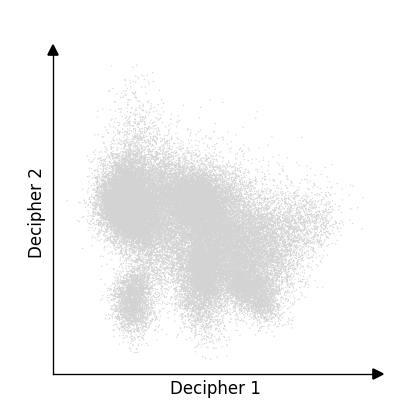

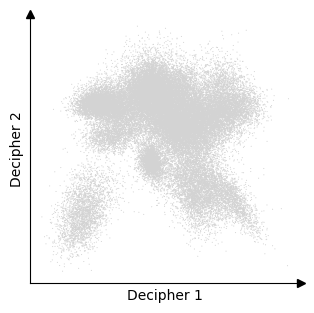

In [8]:
decipher_model_orig, _ = dc.tl.decipher_train(
    adata_tumor_dc_orig,
    decipher_config=config,
)

# Save under a distinct key so it doesn't collide
adata_tumor_dc_orig.obsm['decipher_v_original'] = adata_tumor_dc_orig.obsm['decipher_v'].copy()

In [9]:
#Save model
adata_tumor_dc_orig.write_h5ad('trained_models/adata_tumor_subset_dc_orig.h5ad')

/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data Analysis/.venv/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [ ]:
# Read model
adata_tumor_dc_orig = sc.read_h5ad('trained_models/adata_tumor_subset_dc_orig.h5ad')
# Shorthand for Long Column Names
nut_fusion_col = 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'
biopsy_class_col = 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)'
# Compute differentiation scores
%pip install openpyxl
gene_sigs_df = pd.read_excel('/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/tumor_differentiation_markers.xlsx', sheet_name='undiff v diff markers NC')
sc.tl.score_genes(adata_tumor_dc_orig, gene_list=gene_sigs_df['undiff'], score_name='undiff_score')
sc.tl.score_genes(adata_tumor_dc_orig, gene_list=gene_sigs_df['diff'], score_name='diff_score')


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


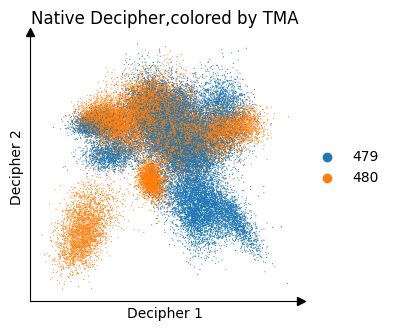

In [ ]:
adata_tumor_dc_orig.obs['TMA'] = adata_tumor_dc_orig.obs['TMA'].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_orig, color='TMA',title='Native Decipher:TMA)

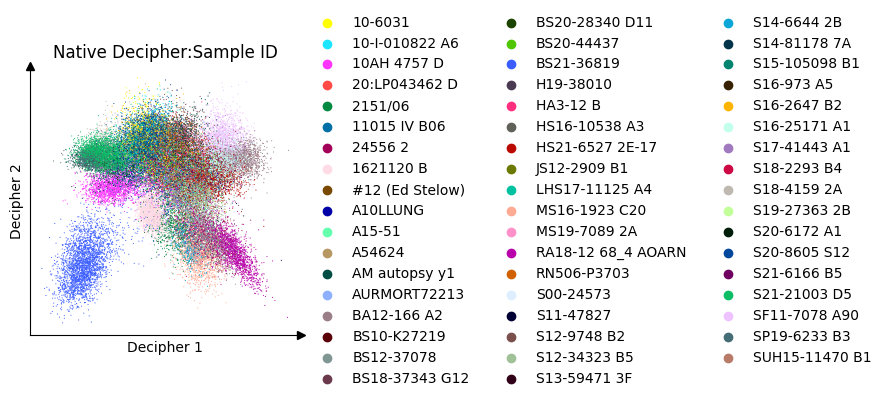

In [17]:
dc.pl.decipher(adata_tumor_dc_orig, color='sample_id',title='Native Decipher:Sample ID')


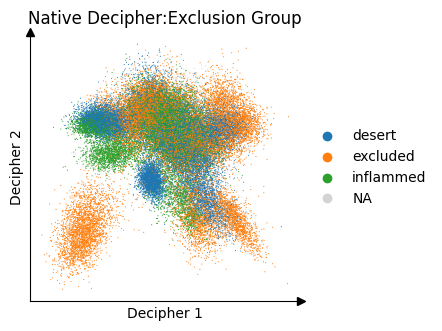

In [18]:
dc.pl.decipher(adata_tumor_dc_orig, color='ex_group', title='Native Decipher:Exclusion Group')


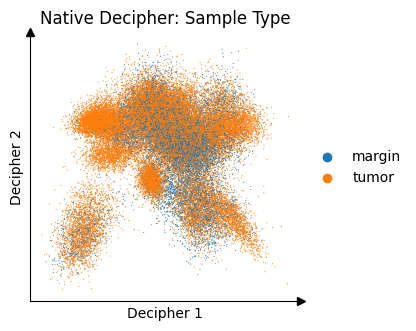

In [19]:
dc.pl.decipher(adata_tumor_dc_orig, color='sample_type',title='Native Decipher: Sample Type')


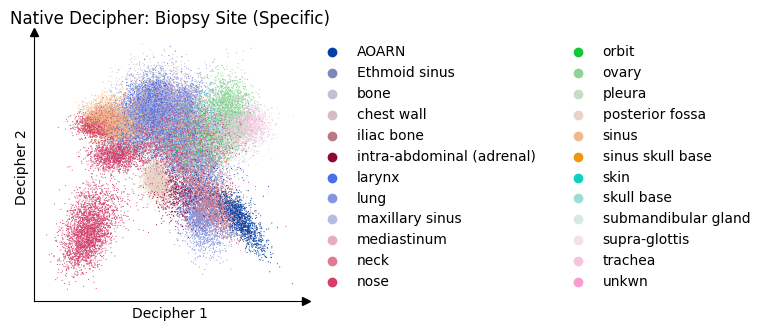

In [21]:
dc.pl.decipher(adata_tumor_dc_orig, color='biopsy_site',title='Native Decipher: Biopsy Site (Specific)')


['2', '3', '0', '1']
Categories (4, object): ['0', '1', '2', '3']


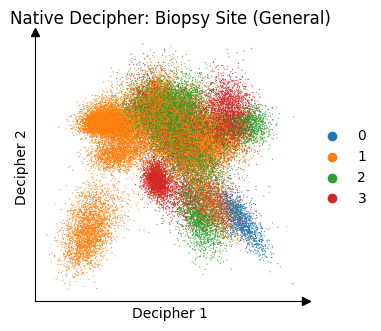

In [29]:
print(adata_tumor_dc_orig.obs[biopsy_class_col].unique())
adata_tumor_dc_orig.obs[biopsy_class_col] = adata_tumor_dc_orig.obs[biopsy_class_col].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_orig, color=biopsy_class_col, title='Native Decipher: Biopsy Site (General)')


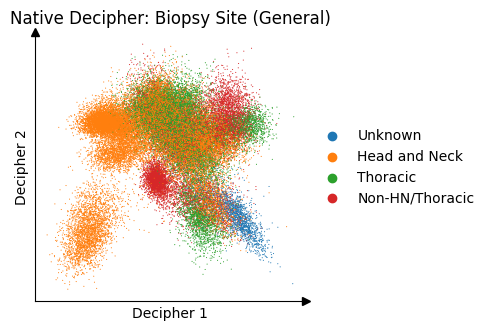

In [30]:
biopsy_class_map = {
    '0': 'Unknown',
    '1': 'Head and Neck',
    '2': 'Thoracic',
    '3': 'Non-HN/Thoracic',
    '4': 'LN'
}

adata_tumor_dc_orig.obs['biopsy_site_class_labeled'] = (
    adata_tumor_dc_orig.obs[biopsy_class_col].map(biopsy_class_map).astype('category')
)

dc.pl.decipher(adata_tumor_dc_orig, color='biopsy_site_class_labeled', title='Native Decipher: Biopsy Site (General)')

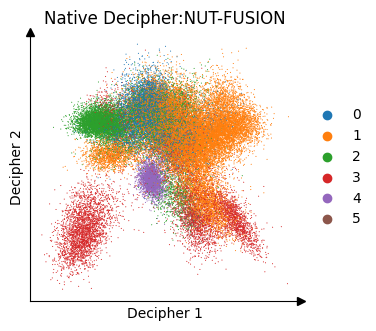

In [32]:
adata_tumor_dc_orig.obs[nut_fusion_col] = adata_tumor_dc_orig.obs[nut_fusion_col].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_orig, color=nut_fusion_col,title='Native Decipher:NUT-FUSION')


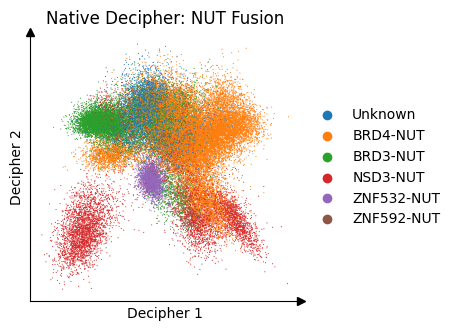

In [35]:
nut_fusion_map = {
    '0': 'Unknown',
    '1': 'BRD4-NUT',
    '2': 'BRD3-NUT',
    '3': 'NSD3-NUT',
    '4': 'ZNF532-NUT',
    '5': 'ZNF592-NUT'
}

adata_tumor_dc_orig.obs['NUT_fusion_labeled'] = (
    adata_tumor_dc_orig.obs[nut_fusion_col].map(nut_fusion_map).astype('category')
)

dc.pl.decipher(adata_tumor_dc_orig, color='NUT_fusion_labeled', title='Native Decipher: NUT Fusion')

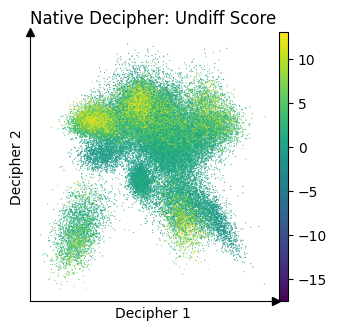

In [37]:
dc.pl.decipher(adata_tumor_dc_orig, color='undiff_score',title='Native Decipher: Undiff Score')

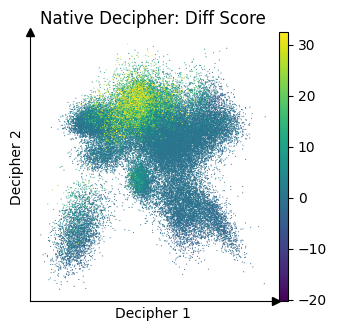

In [39]:
dc.pl.decipher(adata_tumor_dc_orig, color='diff_score',title='Native Decipher: Diff Score')


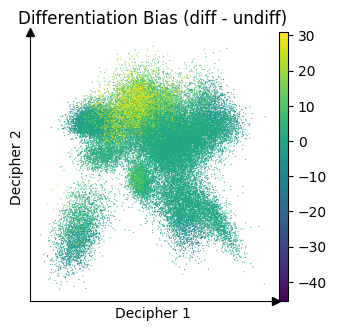

In [40]:
adata_tumor_dc_orig.obs['diff_undiff_ratio'] = (
    adata_tumor_dc_orig.obs['diff_score'] - adata_tumor_dc_orig.obs['undiff_score']
)

dc.pl.decipher(adata_tumor_dc_orig, color='diff_undiff_ratio', title='Differentiation Bias (diff - undiff)')